In [1]:
!curl -O https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzvf korean-english-park.train.tar.gz

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  8.31M 100  8.31M   0      0 43.09M      0                              0
100  8.31M 100  8.31M   0      0 43.08M      0                              0
100  8.31M 100  8.31M   0      0 43.05M      0                              0
x korean-english-park.train.en
x korean-english-park.train.ko


In [2]:
import os

# 주피터 커널의 작업 위치를 10 폴더로 이동
os.chdir('D:/vscode/aiffel/2026/09/10')

# 현재 이동한 위치 확인
print("현재 파이썬 작업 경로:", os.getcwd())

현재 파이썬 작업 경로: D:\vscode\aiffel\2026\09\10


In [3]:
# 로컬 상대 경로 설정
data_dir = "./"
ko_path = os.path.join(data_dir, "korean-english-park.train.ko")
en_path = os.path.join(data_dir, "korean-english-park.train.en")

# 한글 및 영어 데이터 로드
with open(ko_path, "r", encoding="utf-8") as f:
    raw_ko = [line.strip() for line in f.readlines()]

with open(en_path, "r", encoding="utf-8") as f:
    raw_en = [line.strip() for line in f.readlines()]

print(f"✅ 로컬 데이터 로드 완료!")
print(f"전체 한글 문장 수: {len(raw_ko)}")
print(f"전체 영어 문장 수: {len(raw_en)}\n")

# 데이터 샘플 확인
for i in range(3):
    print(f"[{i+1}] KO: {raw_ko[i]}")
    print(f"    EN: {raw_en[i]}\n")

✅ 로컬 데이터 로드 완료!
전체 한글 문장 수: 94123
전체 영어 문장 수: 94123

[1] KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
    EN: Much of personal computing is about "can you top this?"

[2] KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
    EN: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.

[3] KO: 그러나 이것은 또한 책상도 필요로 하지 않는다.
    EN: Like all optical mice, But it also doesn't need a desk.



In [4]:
import re
from sklearn.model_selection import train_test_split
import pandas as pd

MAX_KO_LEN = 100      # 한글 최대 글자 수
MAX_EN_LEN = 200      # 영어 최대 글자 수

# 1. Pandas DataFrame으로 변환 (중복 제거 및 필터링 용이)
df = pd.DataFrame({'ko': raw_ko, 'en': raw_en})

print(f"정제 전 데이터 개수: {len(df)}")

# 2. 중복 데이터 제거 (한글 또는 영어 기준 중복 제거)
df.drop_duplicates(subset=['ko'], inplace=True)
df.drop_duplicates(subset=['en'], inplace=True)

# 3. 빈 문자열(공백) 제거
df = df[df['ko'].str.strip() != '']
df = df[df['en'].str.strip() != '']

def clean_text(text):
    # 1. HTML 태그나 웹 찌꺼기 제거 (필요한 경우)
    text = re.sub(r'<[^>]+>', '', text)
    # 2. 줄바꿈(\n), 탭(\t) 등을 일반 공백 하나로 통일
    text = re.sub(r'[\r\n\t]', ' ', text)
    # 3. 연속된 공백 2개 이상을 공백 1개로 축소
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['ko'] = df['ko'].apply(clean_text)
df['en'] = df['en'].apply(clean_text)
# 5. 문장 길이 기반 필터링 (분포 분석 반영: 한글 100자, 영어 200자 이하)
df = df[
    (df['ko'].str.len() >= 10) & (df['ko'].str.len() <= MAX_KO_LEN) &
    (df['en'].str.len() >= 10) & (df['en'].str.len() <= MAX_EN_LEN)
]
print(f"2. 정제 및 길이 필터링 후 데이터 개수: {len(df)}")

# 6. Train / Valid 세트 80:20 분할
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"\n✅ 최종 학습(Train) 데이터: {len(train_df)}개")
print(f"✅ 최종 검증(Valid) 데이터: {len(val_df)}개")

정제 전 데이터 개수: 94123
2. 정제 및 길이 필터링 후 데이터 개수: 60771

✅ 최종 학습(Train) 데이터: 48616개
✅ 최종 검증(Valid) 데이터: 12155개


=== 한글 문장 길이 통계 ===
최소: 10, 최대: 100, 평균: 57.1, 중앙값: 57.0
90%지점: 84.0, 95%지점: 91.0, 99%지점: 98.0

=== 영어 문장 길이 통계 ===
최소: 10, 최대: 200, 평균: 115.7, 중앙값: 115.0
90%지점: 175.0, 95%지점: 186.0, 99%지점: 197.0



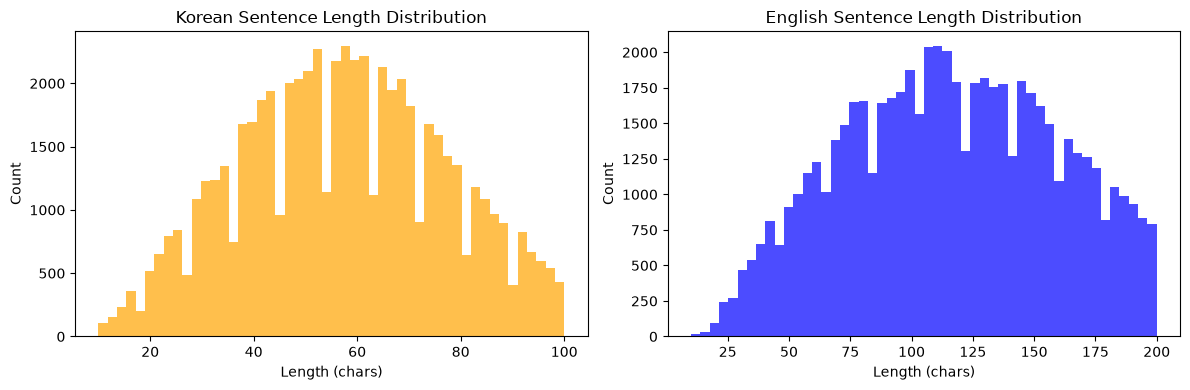

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 글자 수 길이 계산
ko_lens = df['ko'].str.len()
en_lens = df['en'].str.len()

# 주요 백분위수(Percentile) 출력
print("=== 한글 문장 길이 통계 ===")
print(f"최소: {np.min(ko_lens)}, 최대: {np.max(ko_lens)}, 평균: {np.mean(ko_lens):.1f}, 중앙값: {np.median(ko_lens):.1f}")
print(f"90%지점: {np.percentile(ko_lens, 90):.1f}, 95%지점: {np.percentile(ko_lens, 95):.1f}, 99%지점: {np.percentile(ko_lens, 99):.1f}\n")

print("=== 영어 문장 길이 통계 ===")
print(f"최소: {np.min(en_lens)}, 최대: {np.max(en_lens)}, 평균: {np.mean(en_lens):.1f}, 중앙값: {np.median(en_lens):.1f}")
print(f"90%지점: {np.percentile(en_lens, 90):.1f}, 95%지점: {np.percentile(en_lens, 95):.1f}, 99%지점: {np.percentile(en_lens, 99):.1f}\n")

# 시각화 (히스토그램)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(ko_lens, bins=50, color='orange', alpha=0.7)
plt.title('Korean Sentence Length Distribution')
plt.xlabel('Length (chars)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(en_lens, bins=50, color='blue', alpha=0.7)
plt.title('English Sentence Length Distribution')
plt.xlabel('Length (chars)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
import os
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

os.makedirs("tokenizer_data", exist_ok=True)

with open("tokenizer_data/train_ko.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(train_df['ko']))

with open("tokenizer_data/train_en.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(train_df['en']))

VOCAB_SIZE = 8000

# [중요] 스페셜 토큰 순서 명시: [PAD]:0, [SOS]:1, [EOS]:2, [UNK]:3
SPECIAL_TOKENS = ["[PAD]", "[SOS]", "[EOS]", "[UNK]"]

def build_bpe_tokenizer(corpus_file, vocab_size=VOCAB_SIZE):
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    
    trainer = BpeTrainer(
        vocab_size=vocab_size, 
        special_tokens=SPECIAL_TOKENS
    )
    
    tokenizer.train(files=[corpus_file], trainer=trainer)
    tokenizer.unk_token = "[UNK]"
    return tokenizer

print("한글 BPE 토크나이저 재학습 중...")
tokenizer_ko = build_bpe_tokenizer("tokenizer_data/train_ko.txt", vocab_size=VOCAB_SIZE)

print("영어 BPE 토크나이저 재학습 중...")
tokenizer_en = build_bpe_tokenizer("tokenizer_data/train_en.txt", vocab_size=VOCAB_SIZE)

tokenizer_ko.save("tokenizer_ko.json")
tokenizer_en.save("tokenizer_en.json")

print("✅ 수정된 토크나이저 재학습 완료!")

# 토큰 ID 검증 출력
print("\n--- 토큰 ID 설정 검증 ---")
print("EN PAD ID:", tokenizer_en.token_to_id("[PAD]")) # 0 이어야 함
print("EN SOS ID:", tokenizer_en.token_to_id("[SOS]")) # 1 이어야 함
print("EN EOS ID:", tokenizer_en.token_to_id("[EOS]")) # 2 이어야 함
print("EN UNK ID:", tokenizer_en.token_to_id("[UNK]")) # 3 이어야 함
print("KO PAD ID:", tokenizer_ko.token_to_id("[PAD]")) # 0 이어야 함
print("KO SOS ID:", tokenizer_ko.token_to_id("[SOS]")) # 1 이어야 함
print("KO EOS ID:", tokenizer_ko.token_to_id("[EOS]")) # 2 이어야 함
print("KO UNK ID:", tokenizer_ko.token_to_id("[UNK]")) # 3 이어야 함

PAD_IDX = tokenizer_en.token_to_id("[PAD]") # 0
SOS_IDX = tokenizer_en.token_to_id("[SOS]") # 1
EOS_IDX = tokenizer_en.token_to_id("[EOS]") # 2
UNK_IDX = tokenizer_en.token_to_id("[UNK]") # 3

한글 BPE 토크나이저 재학습 중...
영어 BPE 토크나이저 재학습 중...
✅ 수정된 토크나이저 재학습 완료!

--- 토큰 ID 설정 검증 ---
EN PAD ID: 0
EN SOS ID: 1
EN EOS ID: 2
EN UNK ID: 3
KO PAD ID: 0
KO SOS ID: 1
KO EOS ID: 2
KO UNK ID: 3


In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import random

import seaborn # Attention 시각화를 위해 필요!

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)
print("device:", device)   # cuda 가 나와야 GPU 가 잘 연결된 것입니다.

2.5.1+cu121
device: cuda


In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        # max_len x d_model 크기의 0으로 채워진 행렬 생성
        pe = torch.zeros(max_len, d_model)
        
        # pos: [0, 1, 2, ..., max_len-1] (shape: [max_len, 1])
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # 10000^(2i/d_model) 분모 계산 (log 스케일 활용하여 연산 안정성 확보)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        # 짝수 인덱스(2i)에는 sin, 홀수 인덱스(2i+1)에는 cos 적용
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 배치 차원 추가: [max_len, d_model] -> [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        
        # 학습되는 가중치가 아니므로 register_buffer로 등록 (모델 저장 시 함께 저장됨)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        # x에 문장 길이(seq_len)만큼의 위치 인코딩 값을 더해줌
        x = x + self.pe[:, :x.size(1)]
        return x

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, Q, K, V, mask=None):
        # print("★ MultiHeadAttention forward 실행됨! ★")
        batch_size = Q.size(0)
        
        # 1. Linear projection & Split heads: [batch_size, num_heads, seq_len, d_k]
        q = self.W_q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        # print("★ [1] Raw Scores (마스킹 전 첫번째 행):", scores[0, 0, 0, :])

        if mask is not None:
            # print("★ [2] Mask Shape:", mask.shape)
            # print("★ [3] Mask Value (첫번째 행):", mask[0, 0, 0, :] if mask.dim() == 4 else mask[0])
            scores = scores.masked_fill(mask == 0, -1e9)
            # print("★ [4] Scores after Masking:", scores[0, 0, 0, :])

        attn_weights = F.softmax(scores, dim=-1)
        # print("★ [5] Final Attn Weights:", attn_weights[0, 0, 0, :])
        context = torch.matmul(attn_weights, v) # [batch_size, num_heads, q_len, d_k]
        
        # 4. Concatenate heads & Final projection
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.out_proj(context)
        
        return output, attn_weights

In [10]:
# 1. Position-wise Feed-Forward Network
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # [batch_size, seq_len, d_model] -> [batch_size, seq_len, d_ff] -> [batch_size, seq_len, d_model]
        return self.fc2(self.dropout(F.relu(self.fc1(x))))

In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        
        # 1. 핵심 부품 선언
        self.mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
        self.ffn = PositionwiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)
        
        # 2. Add & Norm 및 Dropout 부품 선언
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # --- 서브레이어 1: Multi-Head Attention + Add & Norm ---
        attn_out, attn_weights = self.mha(x, x, x, mask=mask)
        # 잔차 연결(+) -> 드롭아웃 -> LayerNorm
        x = self.norm1(x + self.dropout1(attn_out))
        
        # --- 서브레이어 2: Position-wise Feed-Forward + Add & Norm ---
        ffn_out = self.ffn(x)
        # 잔차 연결(+) -> 드롭아웃 -> LayerNorm
        x = self.norm2(x + self.dropout2(ffn_out))
        
        return x, attn_weights

In [12]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        
        # 1. 단어 임베딩 레이어
        self.tok_embedding = nn.Embedding(vocab_size, d_model)
        
        # 2. 위치 인코딩
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        
        # 3. EncoderLayer를 N개 쌓기 (nn.ModuleList 활용)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # 4. 드롭아웃 및 최종 정규화
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, src, mask=None):
        # src: [batch_size, seq_len] (토크나이저를 거친 단어 ID 정수 텐서)
        
        # 1. 임베딩 연산 & Scale 조절
        # 논문 구현 공식: sqrt(d_model)을 곱해 임베딩 값의 스케일을 늘려줌
        out = self.tok_embedding(src) * np.sqrt(self.d_model)
        
        # 2. Positional Encoding 결합 & Dropout
        out = self.pos_encoding(out)
        out = self.dropout(out)
        
        # 3. N개의 EncoderLayer를 순차적으로 통과
        for layer in self.layers:
            out, _ = layer(out, mask)
            
        # 4. 최종 LayerNorm 적용
        out = self.norm(out)
        
        return out  # [batch_size, seq_len, d_model]

In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        
        self.self_attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
        self.cross_attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
        self.ffn = PositionwiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, tgt, enc_src, tgt_mask=None, src_mask=None):
        # 1. Masked Self-Attention
        _tgt, self_attn_weights = self.self_attn(tgt, tgt, tgt, mask=tgt_mask)
        tgt = self.norm1(tgt + self.dropout1(_tgt))
        
        # 2. Cross-Attention (Q: tgt, K/V: enc_src)
        _tgt, cross_attn_weights = self.cross_attn(Q=tgt, K=enc_src, V=enc_src, mask=src_mask)
        tgt = self.norm2(tgt + self.dropout2(_tgt))
        
        # 3. Feed-Forward
        _tgt = self.ffn(tgt)
        tgt = self.norm3(tgt + self.dropout3(_tgt))
        
        return tgt, self_attn_weights, cross_attn_weights

In [14]:
def generate_square_subsequent_mask(sz, device='cpu'):
    # torch.tril (하삼각 행렬): 자기 자신과 이전 토큰 위치만 True(1)로 설정
    # True: 참조 가능 (Valid), False: 미래 단어 가림 (Masked)
    mask = torch.tril(torch.ones((sz, sz), device=device)).bool()
    return mask

In [15]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        
        self.tok_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, tgt, enc_src, tgt_mask=None, src_mask=None):
        out = self.tok_embedding(tgt) * np.sqrt(self.d_model)
        out = self.pos_encoding(out)
        out = self.dropout(out)

        cross_attns = []  # 모든 레이어의 cross_attn을 담을 리스트

        for layer in self.layers:
             out, self_attn, cross_attn = layer(out, enc_src, tgt_mask=tgt_mask, src_mask=src_mask)
             cross_attns.append(cross_attn)  # 각 레이어의 어텐션 저장

        out = self.norm(out)
        return out, cross_attns  # 리스트 전체 반환

In [16]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=5000, dropout=0.1, pad_idx=0):
        super(Transformer, self).__init__()
        
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.generator = nn.Linear(d_model, tgt_vocab_size)
        self.pad_idx = pad_idx

    def make_pad_mask(self, q, k):
        return (k != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_subsequent_mask(self, tgt):
        tgt_len = tgt.size(1)
        subsequent_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
        return subsequent_mask.unsqueeze(0).unsqueeze(1)

    def forward(self, src, tgt):
        # 1. 마스크 생성
        src_mask = self.make_pad_mask(src, src)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt)
        tgt_sub_mask = self.make_subsequent_mask(tgt)
        
        tgt_mask = tgt_pad_mask & tgt_sub_mask
        src_tgt_mask = self.make_pad_mask(tgt, src)
        
        # 2. 인코더 및 디코더 통과
        enc_src = self.encoder(src, src_mask)
        
        dec_out, cross_attn = self.decoder(tgt, enc_src, tgt_mask=tgt_mask, src_mask=src_tgt_mask)
        
        output = self.generator(dec_out)
        return output

In [17]:

from torch.utils.data import Dataset, DataLoader
import torch

# 1. Dataset 클래스 (SOS, EOS 토큰 추가 완료 버전)
class TranslationDataset(Dataset):
    def __init__(self, df, src_tokenizer, tgt_tokenizer, src_col='ko', tgt_col='en'):
        self.src_sentences = df[src_col].values
        self.tgt_sentences = df[tgt_col].values
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src_text = self.src_sentences[idx]
        tgt_text = self.tgt_sentences[idx]

        src_ids = self.src_tokenizer.encode(src_text).ids
        tgt_ids = self.tgt_tokenizer.encode(tgt_text).ids

        # [SOS], [EOS] 토큰 결합 (SOS_IDX, EOS_IDX가 전역 변수로 선언되어 있어야 함)
        src_ids = [SOS_IDX] + src_ids + [EOS_IDX]
        tgt_ids = [SOS_IDX] + tgt_ids + [EOS_IDX]

        return torch.tensor(src_ids), torch.tensor(tgt_ids)

# 2. 배치 패딩 함수
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_pad = torch.nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_pad = torch.nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)
    return src_pad, tgt_pad

# 3. Dataset 생성
train_dataset = TranslationDataset(train_df, tokenizer_ko, tokenizer_en)
val_dataset = TranslationDataset(val_df, tokenizer_ko, tokenizer_en)

# 4. DataLoader 생성 (이 부분이 지워졌던 부분입니다)
BATCH_SIZE = 64

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("DataLoader 생성 완료! 이제 학습 루프를 실행하세요.")

print("전역변수 PAD_IDX:", PAD_IDX)
print("한국어 토크나이저 PAD ID:", tokenizer_ko.token_to_id("[PAD]"))
print("영어 토크나이저 PAD ID:", tokenizer_en.token_to_id("[PAD]"))
print("=== 특수 토큰 ID 검증 ===")
print(f"한국어 PAD: {tokenizer_ko.token_to_id('[PAD]')} | 영어 PAD: {tokenizer_en.token_to_id('[PAD]')}")
print(f"한국어 SOS: {tokenizer_ko.token_to_id('[SOS]')} | 영어 SOS: {tokenizer_en.token_to_id('[SOS]')}")
print(f"한국어 EOS: {tokenizer_ko.token_to_id('[EOS]')} | 영어 EOS: {tokenizer_en.token_to_id('[EOS]')}")
print(f"전역변수 PAD_IDX: {PAD_IDX}")

DataLoader 생성 완료! 이제 학습 루프를 실행하세요.
전역변수 PAD_IDX: 0
한국어 토크나이저 PAD ID: 0
영어 토크나이저 PAD ID: 0
=== 특수 토큰 ID 검증 ===
한국어 PAD: 0 | 영어 PAD: 0
한국어 SOS: 1 | 영어 SOS: 1
한국어 EOS: 2 | 영어 EOS: 2
전역변수 PAD_IDX: 0


In [18]:
sample_ids = tokenizer_ko.encode("테스트 문장").ids
print("encode 결과:", sample_ids)
print("SOS_IDX:", SOS_IDX)

encode 결과: [5633, 945, 1424]
SOS_IDX: 1


In [19]:
# 아래 코드를 실행해서 전역변수 ID와 토크나이저 실제 ID가 일치하는지 꼭 확인해보세요!
print("SOS_IDX:", SOS_IDX, "| 토크나이저 SOS ID:", tokenizer_ko.token_to_id("[SOS]"))
print("EOS_IDX:", EOS_IDX, "| 토크나이저 EOS ID:", tokenizer_ko.token_to_id("[EOS]"))

SOS_IDX: 1 | 토크나이저 SOS ID: 1
EOS_IDX: 2 | 토크나이저 EOS ID: 2


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 단어장 크기 설정 (학습했던 토크나이저 기준)
SRC_VOCAB_SIZE = tokenizer_ko.get_vocab_size()
TGT_VOCAB_SIZE = tokenizer_en.get_vocab_size()

# 모델 하이퍼파라미터
D_MODEL = 512
NUM_LAYERS = 6
NUM_HEADS = 8
D_FF = 2048
DROPOUT = 0.1

# Transformer 모델 객체 생성
model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

print(f"✅ 모델 생성 및 {device} 할당 완료!")

✅ 모델 생성 및 cuda 할당 완료!


In [21]:
def translate_sentence_fast(model, sentence, max_len=30):
    model.eval()

    with torch.no_grad():
        # 1. 인코더 입력 토큰화 & [SOS], [EOS] 추가
        src_tokens = tokenizer_ko.encode(sentence).ids
        src_tokens = [SOS_IDX] + src_tokens + [EOS_IDX]
        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        
        # 2. 인코더 마스크 생성 및 인코더 통과
        src_mask = model.make_pad_mask(src_tensor, src_tensor)
        enc_src = model.encoder(src_tensor, src_mask)

        tgt_indices = [SOS_IDX]

        # 3. Auto-regressive 디코딩 루프
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long, device=device)

            # 디코더 마스크 생성
            tgt_pad_mask = model.make_pad_mask(tgt_tensor, tgt_tensor)
            tgt_sub_mask = model.make_subsequent_mask(tgt_tensor)
            tgt_mask = tgt_pad_mask & tgt_sub_mask
            
            # Cross-Attention 마스크
            src_tgt_mask = model.make_pad_mask(tgt_tensor, src_tensor)

            # 디코더 연산 및 다음 토큰 확률 예측
            dec_out, _ = model.decoder(tgt_tensor, enc_src, tgt_mask=tgt_mask, src_mask=src_tgt_mask)
            logits = model.generator(dec_out)[:, -1, :] # [1, tgt_vocab_size]

            next_token = logits.argmax(dim=-1).item()

            # 토큰 추가를 break보다 먼저 수행
            tgt_indices.append(next_token)

            # EOS 토큰이 나오면 생성 종료
            if next_token == EOS_IDX:
                break

        # 4. [SOS], [EOS], [PAD] 제거 후 디코딩
        decoded_tokens = [idx for idx in tgt_indices if idx not in (SOS_IDX, EOS_IDX, PAD_IDX)]
        translated = tokenizer_en.decode(decoded_tokens)
        
        return translated if translated.strip() else "(번역 결과 없음)"

In [22]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# 1. 디렉토리 설정 및 모델 가중치 초기화
save_dir = "./checkpoints"
os.makedirs(save_dir, exist_ok=True)
model = model.to(device)

def weights_init(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

model.apply(weights_init)

# 2. 토크나이저 PAD_IDX 지정 및 손실 함수 / 옵티마이저 설정
PAD_IDX = tokenizer_en.token_to_id("[PAD]")
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# 💡 [Fix 1] Transformer 정석 Adam 설정 (lr=1.0 기본 + LambdaLR 곱연산)
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

def rate(step, model_size=512, factor=1.0, warmup=2000):
    if step == 0:
        step = 1
    return factor * (model_size ** (-0.5) * min(step ** (-0.5), step * (warmup ** -1.5)))

scheduler = optim.lr_scheduler.LambdaLR(
    optimizer, 
    lr_lambda=lambda step: rate(step, model_size=512, factor=1.0, warmup=2000)
)

# 3. 매 에포크마다 추론할 테스트 문장
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

# 4. 1 에포크 학습 함수
def train_epoch(model, dataloader, optimizer, scheduler, criterion, device, epoch, total_epochs):
    model.train()
    epoch_loss = 0

    pbar = tqdm(dataloader, desc=f"Epoch [{epoch}/{total_epochs}] Train", leave=False)

    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_label = tgt[:, 1:]

        optimizer.zero_grad()
        logits = model(src, tgt_input)

        # Loss 계산
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_label.reshape(-1))
        loss.backward()
        
        # Gradient Clipping (학습 안정화)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        epoch_loss += loss_val

        pbar.set_postfix({'loss': f'{loss_val:.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.6f}'})

    return epoch_loss / len(dataloader)


# 5. 1 에포크 검증 함수
def evaluate(model, dataloader, criterion, device, epoch, total_epochs):
    model.eval()
    epoch_loss = 0

    pbar = tqdm(dataloader, desc=f"Epoch [{epoch}/{total_epochs}] Eval ", leave=False)

    with torch.no_grad():
        for src, tgt in pbar:
            src, tgt = src.to(device), tgt.to(device)

            tgt_input = tgt[:, :-1]
            tgt_label = tgt[:, 1:]

            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_label.reshape(-1))

            loss_val = loss.item()
            epoch_loss += loss_val

            pbar.set_postfix({'loss': f'{loss_val:.4f}'})

    return epoch_loss / len(dataloader)


# 6. 학습 / 검증 / 실시간 추론 실행 Loop
NUM_EPOCHS = 20
print("=== 학습 / 검증 / 에포크별 실시간 추론 진행 ===")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, criterion, device, epoch, NUM_EPOCHS)
    test_loss = evaluate(model, test_dataloader, criterion, device, epoch, NUM_EPOCHS)
    
    checkpoint_path = os.path.join(save_dir, f"transformer_epoch_{epoch}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'test_loss': test_loss
    }, checkpoint_path)
    
    print(f"\n==========================================")
    print(f" [ Epoch {epoch:02d}/{NUM_EPOCHS} ] | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"==========================================")
    
    for i, sentence in enumerate(test_sentences, 1):
        translated = translate_sentence_fast(model, sentence)
        print(f"  {i}. {sentence}")
        print(f"    ➔ {translated}")
    print()

print("학습 및 실시간 추론 출력이 완료되었습니다!")


=== 학습 / 검증 / 에포크별 실시간 추론 진행 ===



 [ Epoch 01/20 ] | Train Loss: 6.7262 | Test Loss: 5.9442
  1. 오바마는 대통령이다.
    ➔ The Korea is been been not not not not not not not not the first .
  2. 시민들은 도시 속에 산다.
    ➔ The Korea is been been been than the U . S . S . S . S . S . S .
  3. 커피는 필요 없다.
    ➔ The Korea is not not not not not not not not not not .
  4. 일곱 명의 사망자가 발생했다.
    ➔ The Korea is been been been than the U . S . S . S . S . S . S . S .




 [ Epoch 02/20 ] | Train Loss: 5.6516 | Test Loss: 5.4345
  1. 오바마는 대통령이다.
    ➔ The economy is a new .
  2. 시민들은 도시 속에 산다.
    ➔ The world is a first time .
  3. 커피는 필요 없다.
    ➔ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “ “
  4. 일곱 명의 사망자가 발생했다.
    ➔ The Dow has been killed in the first time .




 [ Epoch 03/20 ] | Train Loss: 5.3440 | Test Loss: 5.3037
  1. 오바마는 대통령이다.
    ➔ The White House is not not not not not a good chance to be a new vote .
  2. 시민들은 도시 속에 산다.
    ➔ The new company is a huge , which the world ' s most of the world .
  3. 커피는 필요 없다.
    ➔ " I think it ' s a lot of the world , but I ' re a lot of the world .
  4. 일곱 명의 사망자가 발생했다.
    ➔ The U . S . military said the death toll were killed in the area , the official said .




 [ Epoch 04/20 ] | Train Loss: 5.2102 | Test Loss: 5.1987
  1. 오바마는 대통령이다.
    ➔ Obama has been in the Democratic presidential presidential presidential primary primary polls , and Obama Obama and Obama and Barack Obama and Barack Obama and Barack Obama and Barack Obama
  2. 시민들은 도시 속에 산다.
    ➔ The company is a year , the first - time , and the world ' s most of the world ' s most famous .
  3. 커피는 필요 없다.
    ➔ The new thing is a lot of the first time .
  4. 일곱 명의 사망자가 발생했다.
    ➔ The storm was killed in the northern Baghdad , killing at least 10 people and wounded .



...


 [ Epoch 13/20 ] | Train Loss: 4.4058 | Test Loss: 4.7676
  1. 오바마는 대통령이다.
    ➔ Obama , who has been in the Democratic presidential race .
  2. 시민들은 도시 속에 산다.
    ➔ The new study is the first time of the most famous .
  3. 커피는 필요 없다.
    ➔ The good thing is a good .
  4. 일곱 명의 사망자가 발생했다.
    ➔ The attack happened in the northern city of K aj a , the official said .




 [ Epoch 14/20 ] | Train Loss: 4.3429 | Test Loss: 4.7595
  1. 오바마는 대통령이다.
    ➔ Obama ' s campaign , McCain ' s campaign , Obama ' s campaign , and Obama ' s campaign , Obama ' s campaign , and Obama ' s
  2. 시민들은 도시 속에 산다.
    ➔ The new system is a little bit of the most famous .
  3. 커피는 필요 없다.
    ➔ But the new amounts of people , you can ' t be a good .
  4. 일곱 명의 사망자가 발생했다.
    ➔ The attack happened in the town of the town of the capital , which killed at least 50 people and wounded more than 50 people .




 [ Epoch 15/20 ] | Train Loss: 4.2856 | Test Loss: 4.7555
  1. 오바마는 대통령이다.
    ➔ Clinton ' s campaign is expected to win the White House .
  2. 시민들은 도시 속에 산다.
    ➔ The scientists are using the most common species of the planet .
  3. 커피는 필요 없다.
    ➔ * * * * * * * * * * * * * * * * * * * * * * * * * * * * * *
  4. 일곱 명의 사망자가 발생했다.
    ➔ The explosion occurred in the city of K aj i district , where the blast occurred .




 [ Epoch 16/20 ] | Train Loss: 4.2294 | Test Loss: 4.7365
  1. 오바마는 대통령이다.
    ➔ The Republican presidential candidate , Sen . Hillary Clinton , has been elected in the race .
  2. 시민들은 도시 속에 산다.
    ➔ The researchers say they ' re not going to be able to get a bit of the sun .
  3. 커피는 필요 없다.
    ➔ * * * * * * * * * * * * * * * * * * * * * * * * * * * * * *
  4. 일곱 명의 사망자가 발생했다.
    ➔ The blast killed at least one person , killing at least six people , police and wounding at least one person , police said .



KeyboardInterrupt: 

In [ ]:
import os
import torch
import matplotlib.pyplot as plt

# 1. 체크포인트가 저장된 디렉토리 설정
save_dir = "./checkpoints"
NUM_EPOCHS = 20

# 2. 체크포인트 파일들에서 train_loss와 test_loss 추출
train_losses = []
test_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    ckpt_path = os.path.join(save_dir, f"transformer_epoch_{epoch}.pt")
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location='cpu')
        # 저장할 때 사용했던 키 이름('train_loss', 'test_loss')으로 불러옵니다.
        train_losses.append(ckpt['train_loss'])
        test_losses.append(ckpt['test_loss'])

# 3. 에포크 범위 설정 및 시각화
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(9, 5))

# Train / Test Loss 선 그래프 출력
plt.plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=5)
plt.plot(epochs, test_losses, 'r-s', label='Test/Valid Loss', linewidth=2, markersize=5)

# 레이아웃 및 디자인 적용
plt.title('Transformer Model Training Trajectory', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.xticks(range(1, len(train_losses) + 1, 2))  # 2 에포크 단위 표기
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# 저장 및 화면 출력
plt.tight_layout()
plt.savefig('transformer_loss_curve.png', dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import torch

def setup_korean_font():
    # 한글 폰트(나눔고딕) 설정 및 마이너스 깨짐 방지
    plt.rc('font', family='NanumGothic')
    plt.rc('axes', unicode_minus=False)

def plot_real_attention(sentence):
    setup_korean_font()
    
    model.to(device)
    model.eval()
    attention_list = []

    with torch.no_grad():
        src_tokens = tokenizer_ko.encode(sentence).ids
        src_tokens = [SOS_IDX] + src_tokens + [EOS_IDX]
        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        
        # 1. 인코더 마스크 (Source 패딩 마스크)
        src_mask = model.make_pad_mask(src_tensor, src_tensor)
        enc_src = model.encoder(src_tensor, src_mask)

        tgt_indices = [SOS_IDX]

        for _ in range(30):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long, device=device)
            tgt_pad_mask = model.make_pad_mask(tgt_tensor, tgt_tensor)
            tgt_sub_mask = model.make_subsequent_mask(tgt_tensor)
            tgt_mask = tgt_pad_mask & tgt_sub_mask
            
            # [수정 1] Cross-Attention 마스크 수정
            # tgt와 src 간 Cross-Attention에는 Source 문장의 패딩 마스크(src_mask)를 사용합니다.
            src_tgt_mask = src_mask

            dec_out, attns = model.decoder(tgt_tensor, enc_src, tgt_mask=tgt_mask, src_mask=src_tgt_mask)
            
            if isinstance(attns, (list, tuple)):
                last_attn = attns[-1]
            else:
                last_attn = attns

            # 8개 헤드 평균 -> [batch_size, tgt_len, src_len]
            mean_head_attn = last_attn.mean(dim=1) 
            # 이번 스텝에서 마지막으로 생성된 디코더 토큰의 어텐션 -> [src_len]
            last_token_attn = mean_head_attn[0, -1, :].cpu() 
            
            logits = model.generator(dec_out)[:, -1, :]
            next_token = logits.argmax(dim=-1).item()

            if next_token == EOS_IDX:
                break
                
            # [수정 2] 어텐션 수집 위치 조정
            # 다음 토큰으로 채택된 시점의 어텐션 가중치를 기록합니다.
            attention_list.append(last_token_attn)
            tgt_indices.append(next_token)

    # Label 추출
    src_labels = []
    for idx in src_tokens:
        tok = tokenizer_ko.id_to_token(idx)
        tok = str(idx) if tok is None else tok.replace(' ', '')
        src_labels.append(tok)

    tgt_labels = []
    # [수정 3] tgt_indices[1:] 추출 범위
    for idx in tgt_indices[1:]:
        tok = tokenizer_en.id_to_token(idx)
        tok = str(idx) if tok is None else tok.replace(' ', '')
        tgt_labels.append(tok)

    # attention_list 개수와 tgt_labels 개수를 맞춥니다.
    attn_matrix = torch.stack(attention_list[:len(tgt_labels)], dim=0).numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attn_matrix, 
        xticklabels=src_labels, 
        yticklabels=tgt_labels, 
        cmap='viridis', 
        annot=True, 
        fmt=".2f"
    )

    plt.title(f"Attention Map: '{sentence}'", fontsize=14, pad=12)
    plt.xlabel("Source (Korean)", fontsize=12)
    plt.ylabel("Target (English)", fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("attention_map_real.png", dpi=300)
    plt.show()

# 실행
plot_real_attention("오바마는 대통령이다.")
# plot_real_attention 함수 안에서 heatmap 그리기 바로 직전에 아래 코드를 추가해서 확인해보세요!